In [8]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import csv
import plotly.figure_factory as ff

In [9]:
def qq_func(list1: list[float], list2: list[float]):
    # Создаем 100 точек от 0 до 100 (процентили)
    percentiles = np.linspace(0, 100, 100)
    q1 = np.percentile(list1, percentiles)
    q2 = np.percentile(list2, percentiles)
    
    # --- 3. Построение графика в Plotly ---
    fig = go.Figure()
    
    # Добавляем точки квантилей (Scatter plot)
    fig.add_trace(go.Scatter(
        x=q1, 
        y=q2, 
        mode='markers',
        name='Квантили групп',
        marker=dict(color='royalblue', size=7, opacity=0.8)
    ))
    
    # Добавляем опорную линию (y = x)
    # Если распределения одинаковые, точки лягут ровно на эту красную пунктирную линию
    min_val = min(min(q1), min(q2))
    max_val = max(max(q1), max(q2))
    
    fig.add_trace(go.Scatter(
        x=[min_val, max_val], 
        y=[min_val, max_val], 
        mode='lines',
        name='Опорная линия (y=x)',
        line=dict(color='red', dash='dash', width=2)
    ))
    
    # Настраиваем внешний вид (Layout)
    fig.update_layout(
        title='Two-Sample Q-Q Plot: Сравнение двух списков данных',
        xaxis_title='Квантили Базовый контекст',
        yaxis_title='Квантили Модификация',
        width=700,
        height=700,
        template='plotly_white',  # Светлая тема
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
    )
    return fig

In [10]:
def read_df(path: str):
    df = pd.read_csv(path, quoting=csv.QUOTE_NONNUMERIC, index_col=0)
    df.index = df.index.astype(int)
    return df

- in_perturb_0 - first - perturb5
- in_perturb_1 - mean - perturb5
- in_perturb_2 - first - perturb10
- in_perturb_3 - mean - perturb10

In [11]:
in_checks = "../data/samples_50/test2/checks.csv"
in_perturb_0 = "../data/samples_50/test2/metrics1/perturb1/generate/ptb_results.csv"
in_perturb_1 = "../data/samples_50/test2/metrics2/perturb1/generate/ptb_results.csv"
in_perturb_2 = "../data/samples_50/test2/metrics1/perturb2/generate/ptb_results.csv"
in_perturb_3 = "../data/samples_50/test2/metrics2/perturb2/generate/ptb_results.csv"

base = read_df(in_checks)
perturb_0 = read_df(in_perturb_0)
perturb_1 = read_df(in_perturb_1)
perturb_2 = read_df(in_perturb_2)
perturb_3 = read_df(in_perturb_3)

In [12]:
# --- 1. Подготовка данных ---
# Замените эти списки на ваши реальные данные
# Для примера сгенерируем две группы (разного размера, но похожие по природе)
list1 = base["similarity"].tolist()
list2_0 = perturb_0["similarity"].tolist()
list2_1 = perturb_1["similarity"].tolist()
list2_2 = perturb_2["similarity"].tolist()
list2_3 = perturb_3["similarity"].tolist()

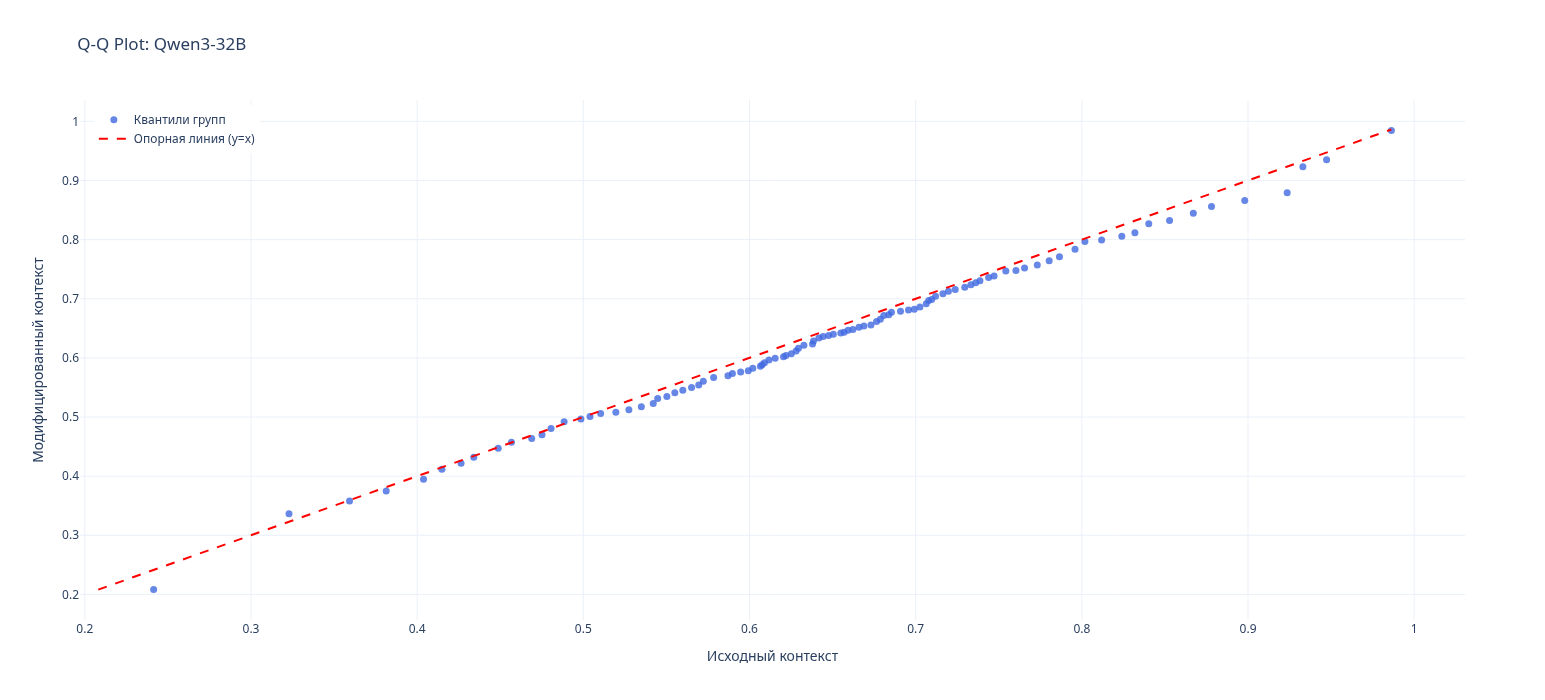

In [13]:
fig = qq_func(list1, list2_2)
# Показываем график
fig.update_layout(
    title='Q-Q Plot: Qwen3-32B',
    xaxis_title='Исходный контекст',
    yaxis_title='Модифицированный контекст',
)
fig.show()

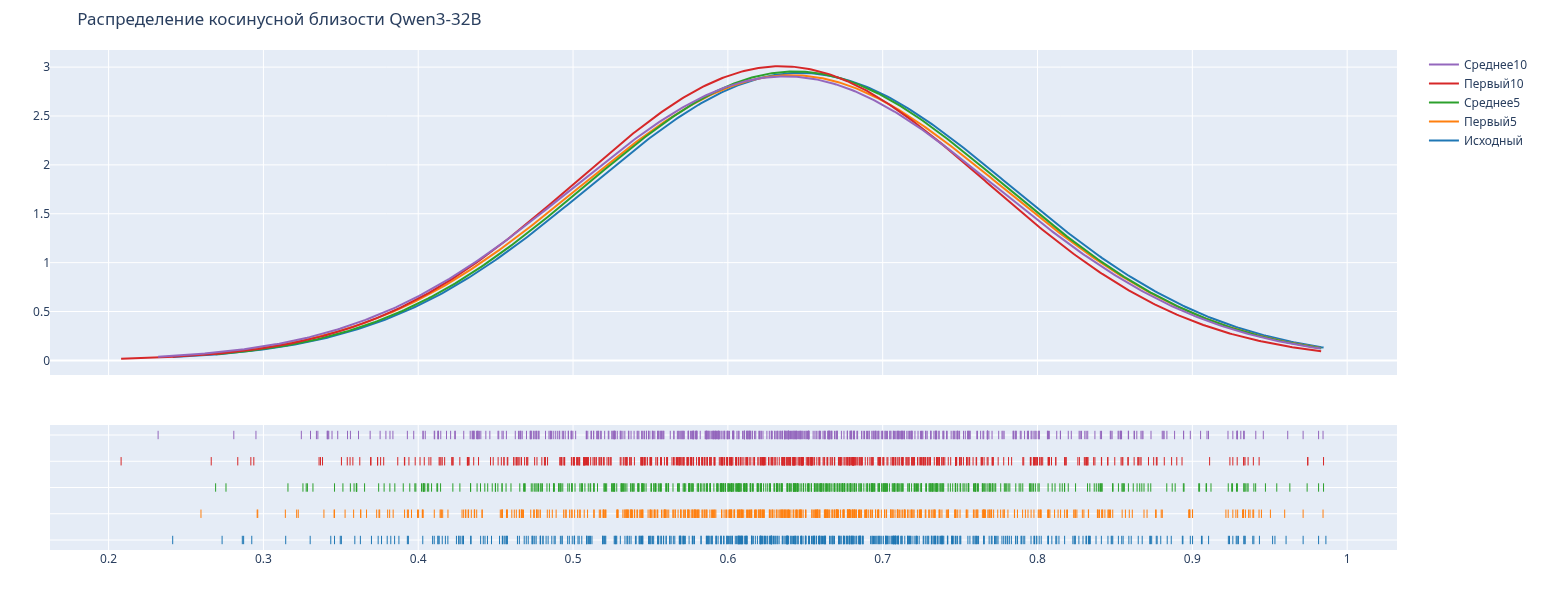

In [14]:
group_labels = ['Исходный', 'Первый5', 'Среднее5', 'Первый10', 'Среднее10']

# Create distplot with curve_type set to 'normal'
fig = ff.create_distplot(
    [
        base["similarity"],
        perturb_0["similarity"],
        perturb_1["similarity"],
        perturb_2["similarity"],
        perturb_3["similarity"],
    ], group_labels, 
    bin_size=.01,
    curve_type='normal', # override default 'kde'
    show_hist=False,
    rug_text=[
        base.index,
        perturb_0.index,
        perturb_1.index,
        perturb_2.index,
        perturb_3.index,
    ]
)

# Add title
fig.update_layout(title_text='Распределение косинусной близости Qwen3-32B')
# 3. Настраиваем ширину, высоту и другие параметры макета
fig.update_layout(
    width=1200,   # Ширина в пикселях
    height=600,  # Высота в пикселях
    margin=dict(l=50, r=50, t=50, b=50) # Отступы от краев (опционально)
)
fig.show()

In [15]:
group_labels = ['Исходный', 'Первый5', 'Среднее5', 'Первый10', 'Среднее10']
group_values = [
    base["similarity"],
    perturb_0["similarity"],
    perturb_1["similarity"],
    perturb_2["similarity"],
    perturb_3["similarity"],
]

In [17]:
# Преобразуем каждый список в pd.Series и объединяем по столбцам (axis=1)
df = pd.concat([pd.Series(v, name=k) for k, v in zip(group_labels, group_values)], axis=1)

# Получаем статистики распределения
stats = df.describe().round(4)

stats

,Исходный,Первый5,Среднее5,Первый10,Среднее10
count,549.0000,549.0000,549.0000,549.0000,549.0000
mean,0.6468,0.6407,0.6434,0.6343,0.6369
std,0.1358,0.1369,0.1351,0.1327,0.1374
min,0.2414,0.2597,0.2691,0.2081,0.2320
25%,0.5633,0.5535,0.5565,0.5481,0.5487
50%,0.6500,0.6421,0.6440,0.6388,0.6382
75%,0.7314,0.7238,0.7305,0.7198,0.7260
max,0.9863,0.9844,0.9847,0.9847,0.9844


In [21]:
stats.T

,count,mean,std,min,25%,50%,75%,max
Исходный,549.0,0.6468,0.1358,0.2414,0.5633,0.6500,0.7314,0.9863
Первый5,549.0,0.6407,0.1369,0.2597,0.5535,0.6421,0.7238,0.9844
Среднее5,549.0,0.6434,0.1351,0.2691,0.5565,0.6440,0.7305,0.9847
Первый10,549.0,0.6343,0.1327,0.2081,0.5481,0.6388,0.7198,0.9847
Среднее10,549.0,0.6369,0.1374,0.2320,0.5487,0.6382,0.7260,0.9844
